# Home task: neural network

## Breast Cancer Dataset

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

X, y = load_breast_cancer(return_X_y=True)
print('X.shape= ', X.shape)
print('y.shape= ', y.shape)

# YOUR_CODE.  Preproces data, train classifier and evaluate the perfromance on train and test sets 
# START_CODE
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = MLPClassifier(
    hidden_layer_sizes=(20, 7, 10),
    solver='lbfgs',
    alpha=0.1,
    max_iter=300,
    random_state=20
)

clf.fit(X_train_scaled, y_train)

print("train accuracy= {:.3%}".format(clf.score(X_train_scaled, y_train)))
print("test accuracy= {:.3%}".format(clf.score(X_test_scaled, y_test)))
# END_CODE

X.shape=  (569, 30)
y.shape=  (569,)
train accuracy= 100.000%
test accuracy= 95.105%


## Signs Dataset

In [12]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

path = "data"

# signs data set (fingers)
def load_dataset():
    fn =  os.path.join(path , 'train_signs.h5')
    train_dataset = h5py.File(fn, "r")
    X_train = np.array(train_dataset["train_set_x"][:]) # your train set features
    y_train = np.array(train_dataset["train_set_y"][:]) # your train set labels

    fn =  os.path.join(path , 'test_signs.h5')
    test_dataset =  h5py.File(fn, "r")
    X_test = np.array(test_dataset["test_set_x"][:]) # your test set features
    y_test = np.array(test_dataset["test_set_y"][:]) # your test set labels

    classes = np.array(test_dataset["list_classes"][:]) # the list of classes
    
    y_train = y_train.reshape((1, y_train.shape[0]))
    y_test = y_test.reshape((1, y_test.shape[0]))
    
    return X_train, y_train, X_test, y_test, classes

X_train, y_train, X_test, y_test, classes = load_dataset()
y_train = y_train.ravel()
y_test = y_test.ravel()

print('X_train.shape=', X_train.shape)
print('X_test.shape=', X_test.shape)
print('y_train.shape=', y_train.shape)
print('y_test.shape=', y_test.shape)

X_train.shape= (1080, 64, 64, 3)
X_test.shape= (120, 64, 64, 3)
y_train.shape= (1080,)
y_test.shape= (120,)


## Sample Images

Here I display several training images from the signs dataset.

c:\Users\User\anaconda3\envs\oldsklearn\lib\site-packages\ipykernel_launcher.py:18: MatplotlibDeprecationWarning: 
The set_window_title function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use `.FigureManagerBase.set_window_title` or GUI-specific methods instead.


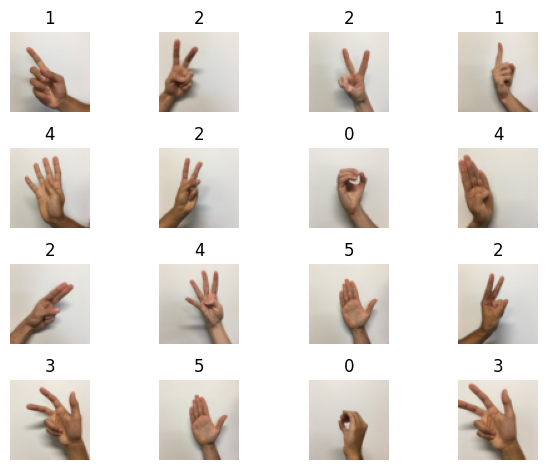

In [13]:
def display_samples_in_grid(X, n_rows, n_cols= None, y = None ):
    if n_cols is None: 
        n_cols= n_rows
    indices = np.random.randint(0, len(X), n_rows * n_cols)
    for i in range(n_rows): 
        for j in range(n_cols):
            index = n_rows * i + j           
            ax = plt.subplot(n_rows, n_cols, index + 1) 
            plt.imshow(X[indices[index]])
            if not (y is None):
                plt.title(y[indices[index]])
            plt.axis('off')

    plt.tight_layout(h_pad=1)

plt.figure()
display_samples_in_grid(X_train, n_rows=4, y=y_train)
plt.gcf().canvas.set_window_title('Train set')

## Data Preprocessing

In [14]:
# Not in use 
def convert_to_one_hot(Y, C):
    Y = np.eye(C)[Y.reshape(-1)]
    return Y

# YOUR_CODE.  Preproces data
# START_CODE
X_train_scaled = X_train.reshape(X_train.shape[0], -1) / 255.
X_test_scaled = X_test.reshape(X_test.shape[0], -1) / 255.
# END_CODE     

print("number of training examples = " + str(X_train_scaled.shape[1]))
print("number of test examples = " + str(X_test_scaled.shape[1]))
print("X_train_scaled shape: " + str(X_train_scaled.shape))
print("X_test_scaled shape: " + str(X_test_scaled.shape))

number of training examples = 12288
number of test examples = 12288
X_train_scaled shape: (1080, 12288)
X_test_scaled shape: (120, 12288)


## Model Training and Evaluation

In [15]:
from sklearn.neural_network import MLPClassifier

# YOUR_CODE.  Train classifier and evaluate the perfromance on train and test sets 
# START_CODE
clf = MLPClassifier(
    hidden_layer_sizes=(200, 100),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    max_iter=1000,
    random_state=42
)

clf.fit(X_train_scaled, y_train)

print("train accuracy= {:.3%}".format(clf.score(X_train_scaled, y_train)))
print("test accuracy= {:.3%}".format(clf.score(X_test_scaled, y_test)))
# END_CODE

train accuracy= 93.426%
test accuracy= 82.500%


## Prediction Results

c:\Users\User\anaconda3\envs\oldsklearn\lib\site-packages\ipykernel_launcher.py:7: MatplotlibDeprecationWarning: 
The set_window_title function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use `.FigureManagerBase.set_window_title` or GUI-specific methods instead.
  import sys


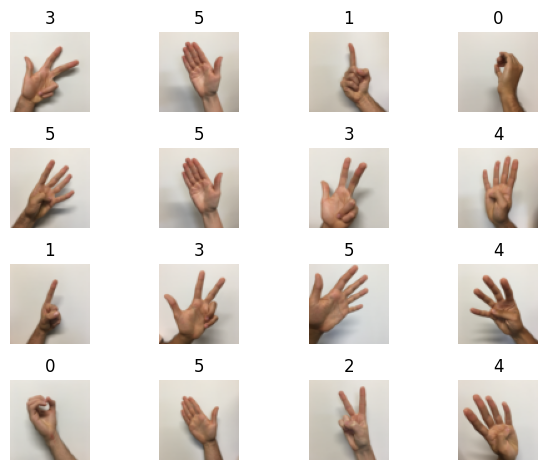

In [16]:
plt.figure()

predicted = clf.predict(X_test_scaled)

display_samples_in_grid(X_test, n_rows=4, y=predicted)

plt.gcf().canvas.set_window_title('Test set prediction')

## Comparison with SVM

In [17]:
from sklearn.svm import SVC

clf = SVC(C=10, kernel='rbf', gamma=0.001).fit(X_train_scaled, y_train)
print("train accuracy= {:.3%}".format(clf.score(X_train_scaled, y_train)))
print("test accuracy= {:.3%}".format(clf.score(X_test_scaled, y_test)))

train accuracy= 99.907%
test accuracy= 95.833%
